In [81]:
from pathlib import Path

import pandas as pd

# Lê cada tabela de local como um DataFrame.
pasta_csv = Path("csv_por_local")
arquivos_csv = sorted(pasta_csv.glob("*.csv"))

if not arquivos_csv:
    raise FileNotFoundError(
        f"Nenhum CSV foi encontrado na pasta: {pasta_csv.resolve()}"
    )

dataframes_por_local = {}

for arquivo_csv in arquivos_csv:
    dataframe = pd.read_csv(arquivo_csv)
    dataframe["Rn"] = dataframe["SWnet"] + dataframe["LWnet"]
    dataframe["Gres"] = dataframe["Rn"] - dataframe["H"] - dataframe["LE"]
    region_id = dataframe.loc[dataframe.index[0], "region_id"]

    # Dicionário com todos os DataFrames: dataframes_por_local["AMZ01"], por exemplo.
    dataframes_por_local[region_id] = dataframe

    # Também cria variáveis individuais: df_AMZ01, df_CER01, etc.
    globals()[f"df_{region_id}"] = dataframe

resumo_locais = pd.DataFrame(
    [
        {
            "region_id": region_id,
            "region_name": dataframe["region_name"].iloc[0],
            "registros": len(dataframe),
            "colunas": len(dataframe.columns),
        }
        for region_id, dataframe in dataframes_por_local.items()
    ]
).sort_values("region_id", ignore_index=True)

print(f"{len(dataframes_por_local)} DataFrames criados.")
display(resumo_locais)


20 DataFrames criados.


,region_id,region_name,registros,colunas
0,AGR01,Agricultura_Sorriso_MT,336,22
1,AGR02,Agricultura_Oeste_Bahia,336,22
2,AGR03,Agricultura_Norte_Parana,336,22
3,AGR04,Agricultura_SP,336,22
4,AMZ01,Amazonia_Central_AM,336,22
5,AMZ02,Amazonia_Tapajos_PA,336,22
6,AMZ03,Amazonia_Sul_AM,336,22
7,AMZ04,Amazonia_Madeira_AM,336,22
8,CAA01,Caatinga_Bahia,336,22
9,CAA02,Caatinga_Pernambuco,336,22


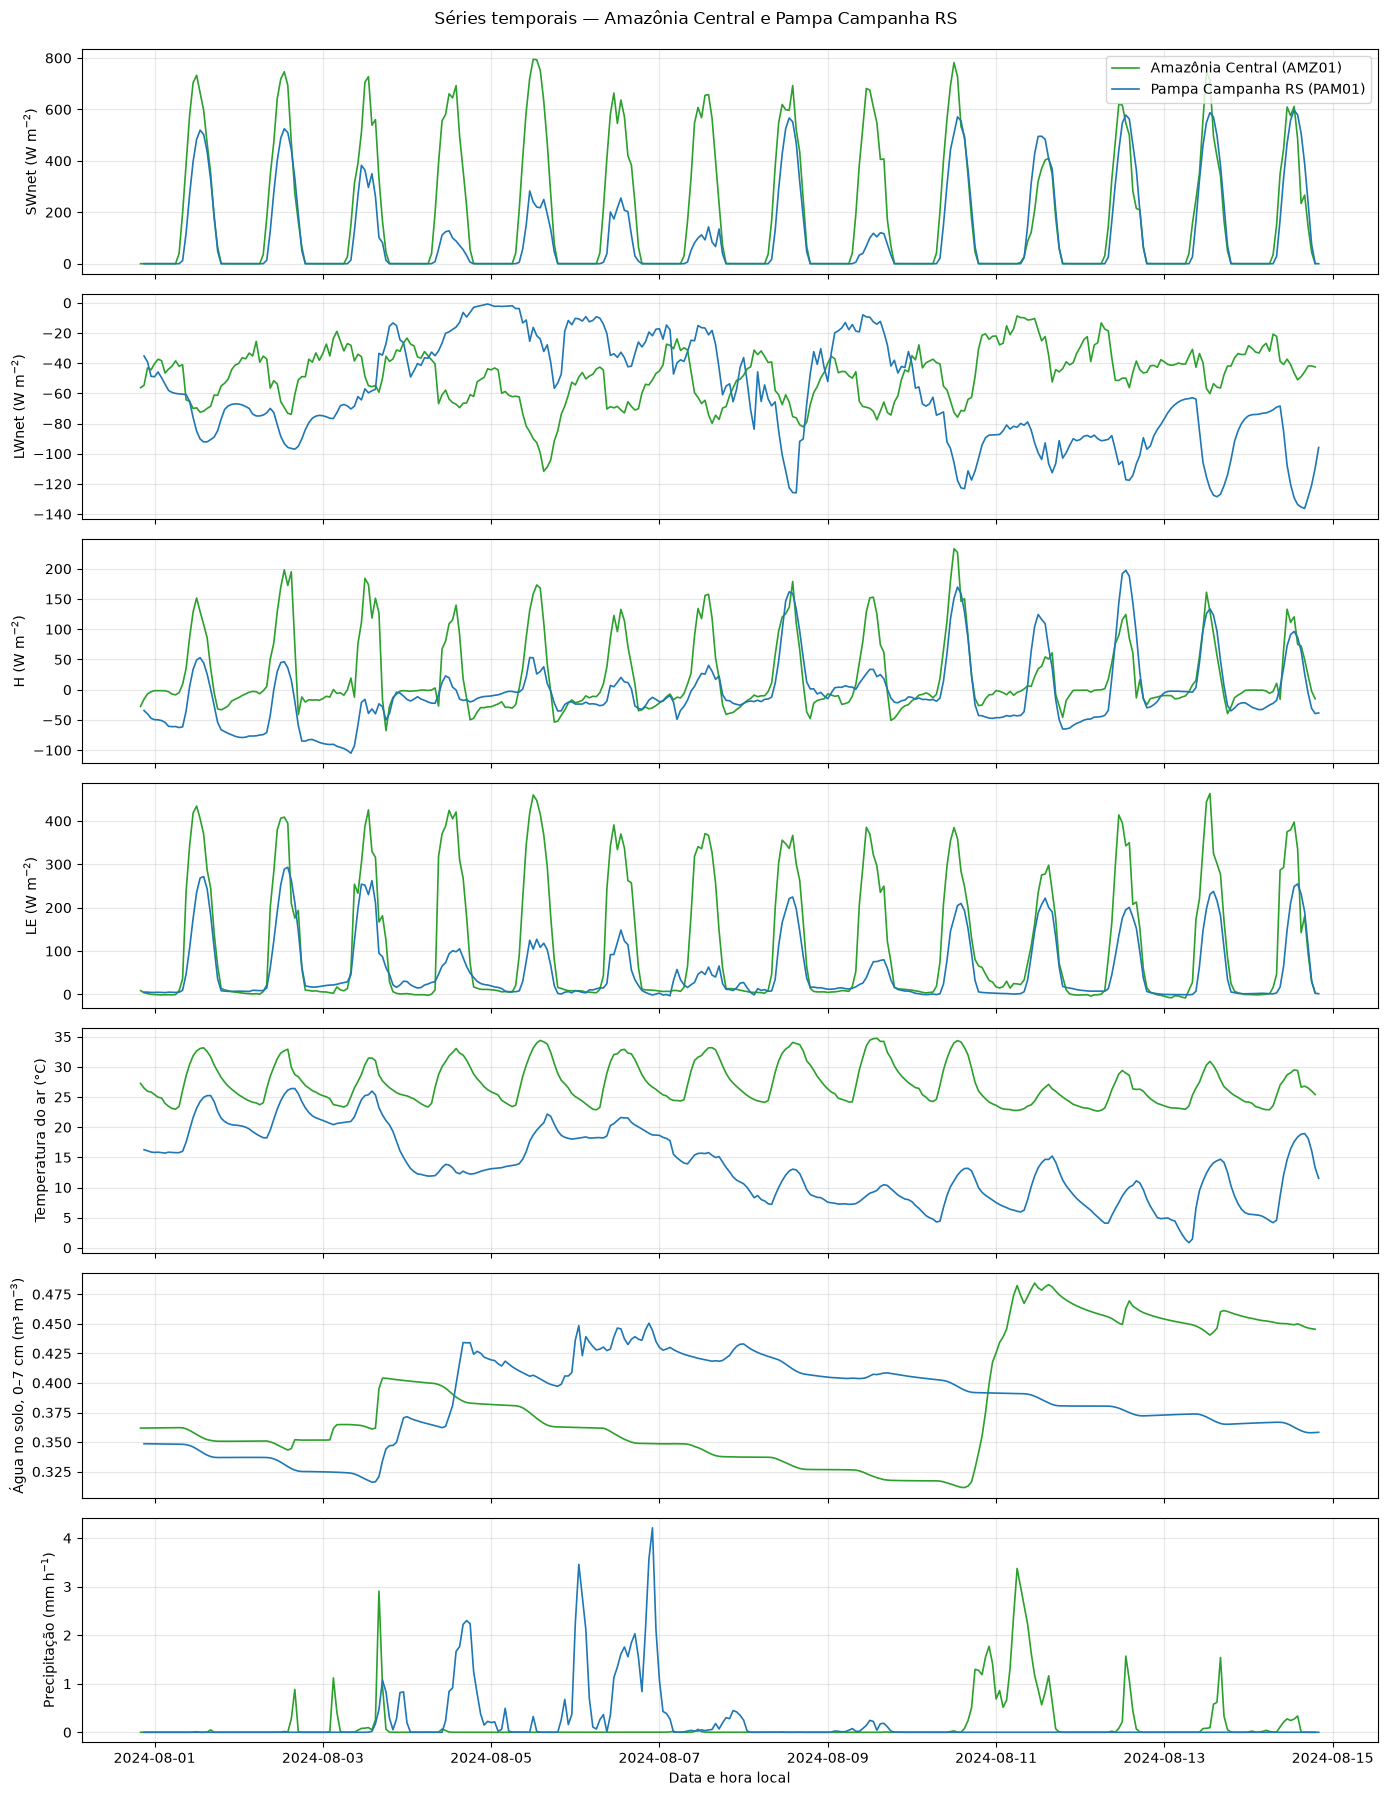

In [82]:
import matplotlib.pyplot as plt

# Séries temporais: Amazônia Central (AMZ01) e Pampa Campanha RS (PAM01).
locais_grafico = {
    "AMZ01": "Amazônia Central (AMZ01)",
    "PAM01": "Pampa Campanha RS (PAM01)",
}

# No arquivo de dados, temperatura é T2m_C e água do solo é soil_water_0_7cm.
variaveis_grafico = {
    "SWnet": "SWnet (W m$^{-2}$)",
    "LWnet": "LWnet (W m$^{-2}$)",
    "H": "H (W m$^{-2}$)",
    "LE": "LE (W m$^{-2}$)",
    "T2m_C": "Temperatura do ar (°C)",
    "soil_water_0_7cm": "Água no solo, 0–7 cm (m³ m$^{-3}$)",
    "precip_mm_h": "Precipitação (mm h$^{-1}$)",
}

cores = {"AMZ01": "tab:green", "PAM01": "tab:blue"}
figura, eixos = plt.subplots(
    nrows=len(variaveis_grafico), ncols=1, figsize=(14, 18), sharex=True
)

for eixo, (variavel, rotulo) in zip(eixos, variaveis_grafico.items()):
    for region_id, nome_local in locais_grafico.items():
        dataframe = dataframes_por_local[region_id]
        datas = pd.to_datetime(dataframe["datetime_local"])
        eixo.plot(
            datas,
            dataframe[variavel],
            label=nome_local,
            color=cores[region_id],
            linewidth=1.2,
        )

    eixo.set_ylabel(rotulo)
    eixo.grid(True, alpha=0.3)

eixos[0].legend(loc="upper right")
eixos[-1].set_xlabel("Data e hora local")
figura.suptitle("Séries temporais — Amazônia Central e Pampa Campanha RS", y=0.995)
figura.tight_layout()
plt.show()


In [83]:
# Horários dos máximos de Rn, H e LE: 09 a 11 de agosto de 2024.
inicio_maximos = pd.Timestamp("2024-08-09 00:00")
fim_maximos = pd.Timestamp("2024-08-12 00:00")  # exclusivo

resultados_maximos = []

for region_id, nome_local in locais_grafico.items():
    dataframe = dataframes_por_local[region_id].copy()
    dataframe["datetime_local"] = pd.to_datetime(dataframe["datetime_local"])
    dados_periodo = dataframe.loc[
        (dataframe["datetime_local"] >= inicio_maximos)
        & (dataframe["datetime_local"] < fim_maximos)
    ]

    for variavel in ["Rn", "H", "LE"]:
        indice_maximo = dados_periodo[variavel].idxmax()
        registro_maximo = dados_periodo.loc[indice_maximo]
        resultados_maximos.append(
            {
                "region_id": region_id,
                "local": nome_local,
                "variavel": variavel,
                "valor_maximo_W_m2": registro_maximo[variavel],
                "data_hora_local": registro_maximo["datetime_local"],
                "hora_local": registro_maximo["hour_local"],
            }
        )

maximos_fluxos = pd.DataFrame(resultados_maximos).sort_values(
    ["region_id", "variavel"], ignore_index=True
)
display(maximos_fluxos)


,region_id,local,variavel,valor_maximo_W_m2,data_hora_local,hora_local
0,AMZ01,Amazônia Central (AMZ01),H,233.095619,2024-08-10 12:00:00,12
1,AMZ01,Amazônia Central (AMZ01),LE,385.351911,2024-08-09 11:00:00,11
2,AMZ01,Amazônia Central (AMZ01),Rn,709.587793,2024-08-10 12:00:00,12
3,PAM01,Pampa Campanha RS (PAM01),H,169.720010,2024-08-10 13:00:00,13
4,PAM01,Pampa Campanha RS (PAM01),LE,221.960197,2024-08-11 14:00:00,14
5,PAM01,Pampa Campanha RS (PAM01),Rn,453.291696,2024-08-10 13:00:00,13


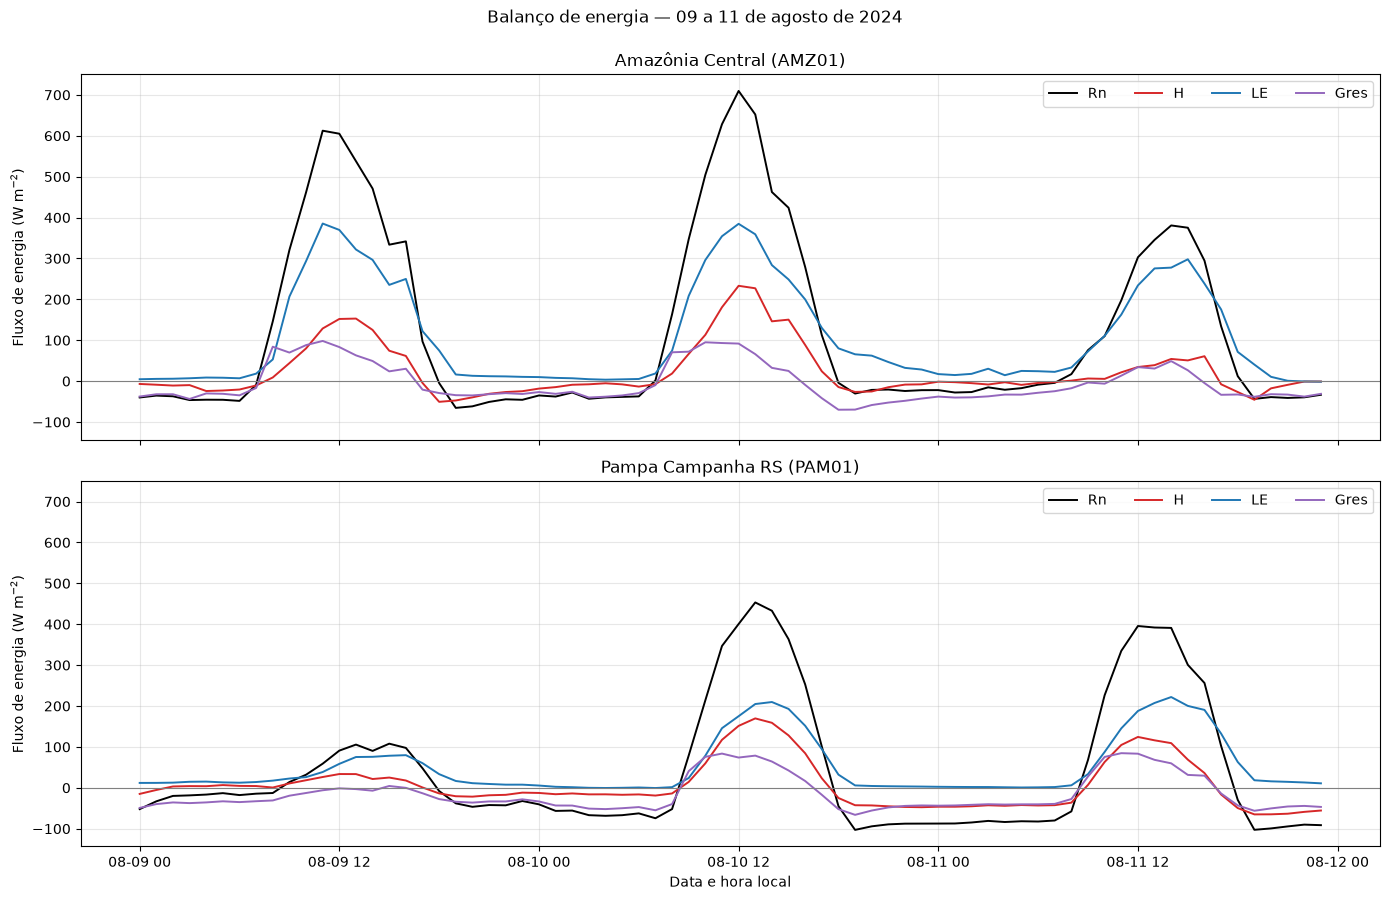

In [84]:
# Componentes do balanço de energia no mesmo período de três dias.
inicio_periodo = pd.Timestamp("2024-08-09 00:00")
fim_periodo = pd.Timestamp("2024-08-12 00:00")  # exclusivo: inclui 09, 10 e 11/08

variaveis_balanco = {
    "Rn": "Rn",
    "H": "H",
    "LE": "LE",
    "Gres": "Gres",
}
cores_balanco = {
    "Rn": "black",
    "H": "tab:red",
    "LE": "tab:blue",
    "Gres": "tab:purple",
}

figura_balanco, eixos_balanco = plt.subplots(
    nrows=len(locais_grafico), ncols=1, figsize=(14, 9), sharex=True, sharey=True
)

for eixo, (region_id, nome_local) in zip(eixos_balanco, locais_grafico.items()):
    dataframe = dataframes_por_local[region_id]
    datas = pd.to_datetime(dataframe["datetime_local"])
    no_periodo = (datas >= inicio_periodo) & (datas < fim_periodo)

    for variavel, rotulo in variaveis_balanco.items():
        eixo.plot(
            datas[no_periodo],
            dataframe.loc[no_periodo, variavel],
            label=rotulo,
            color=cores_balanco[variavel],
            linewidth=1.4,
        )

    eixo.axhline(0, color="gray", linewidth=0.8)
    eixo.set_title(nome_local)
    eixo.set_ylabel("Fluxo de energia (W m$^{-2}$)")
    eixo.grid(True, alpha=0.3)
    eixo.legend(ncol=4, loc="upper right")

eixos_balanco[-1].set_xlabel("Data e hora local")
figura_balanco.suptitle(
    "Balanço de energia — 09 a 11 de agosto de 2024", y=0.995
)
figura_balanco.tight_layout()
plt.show()


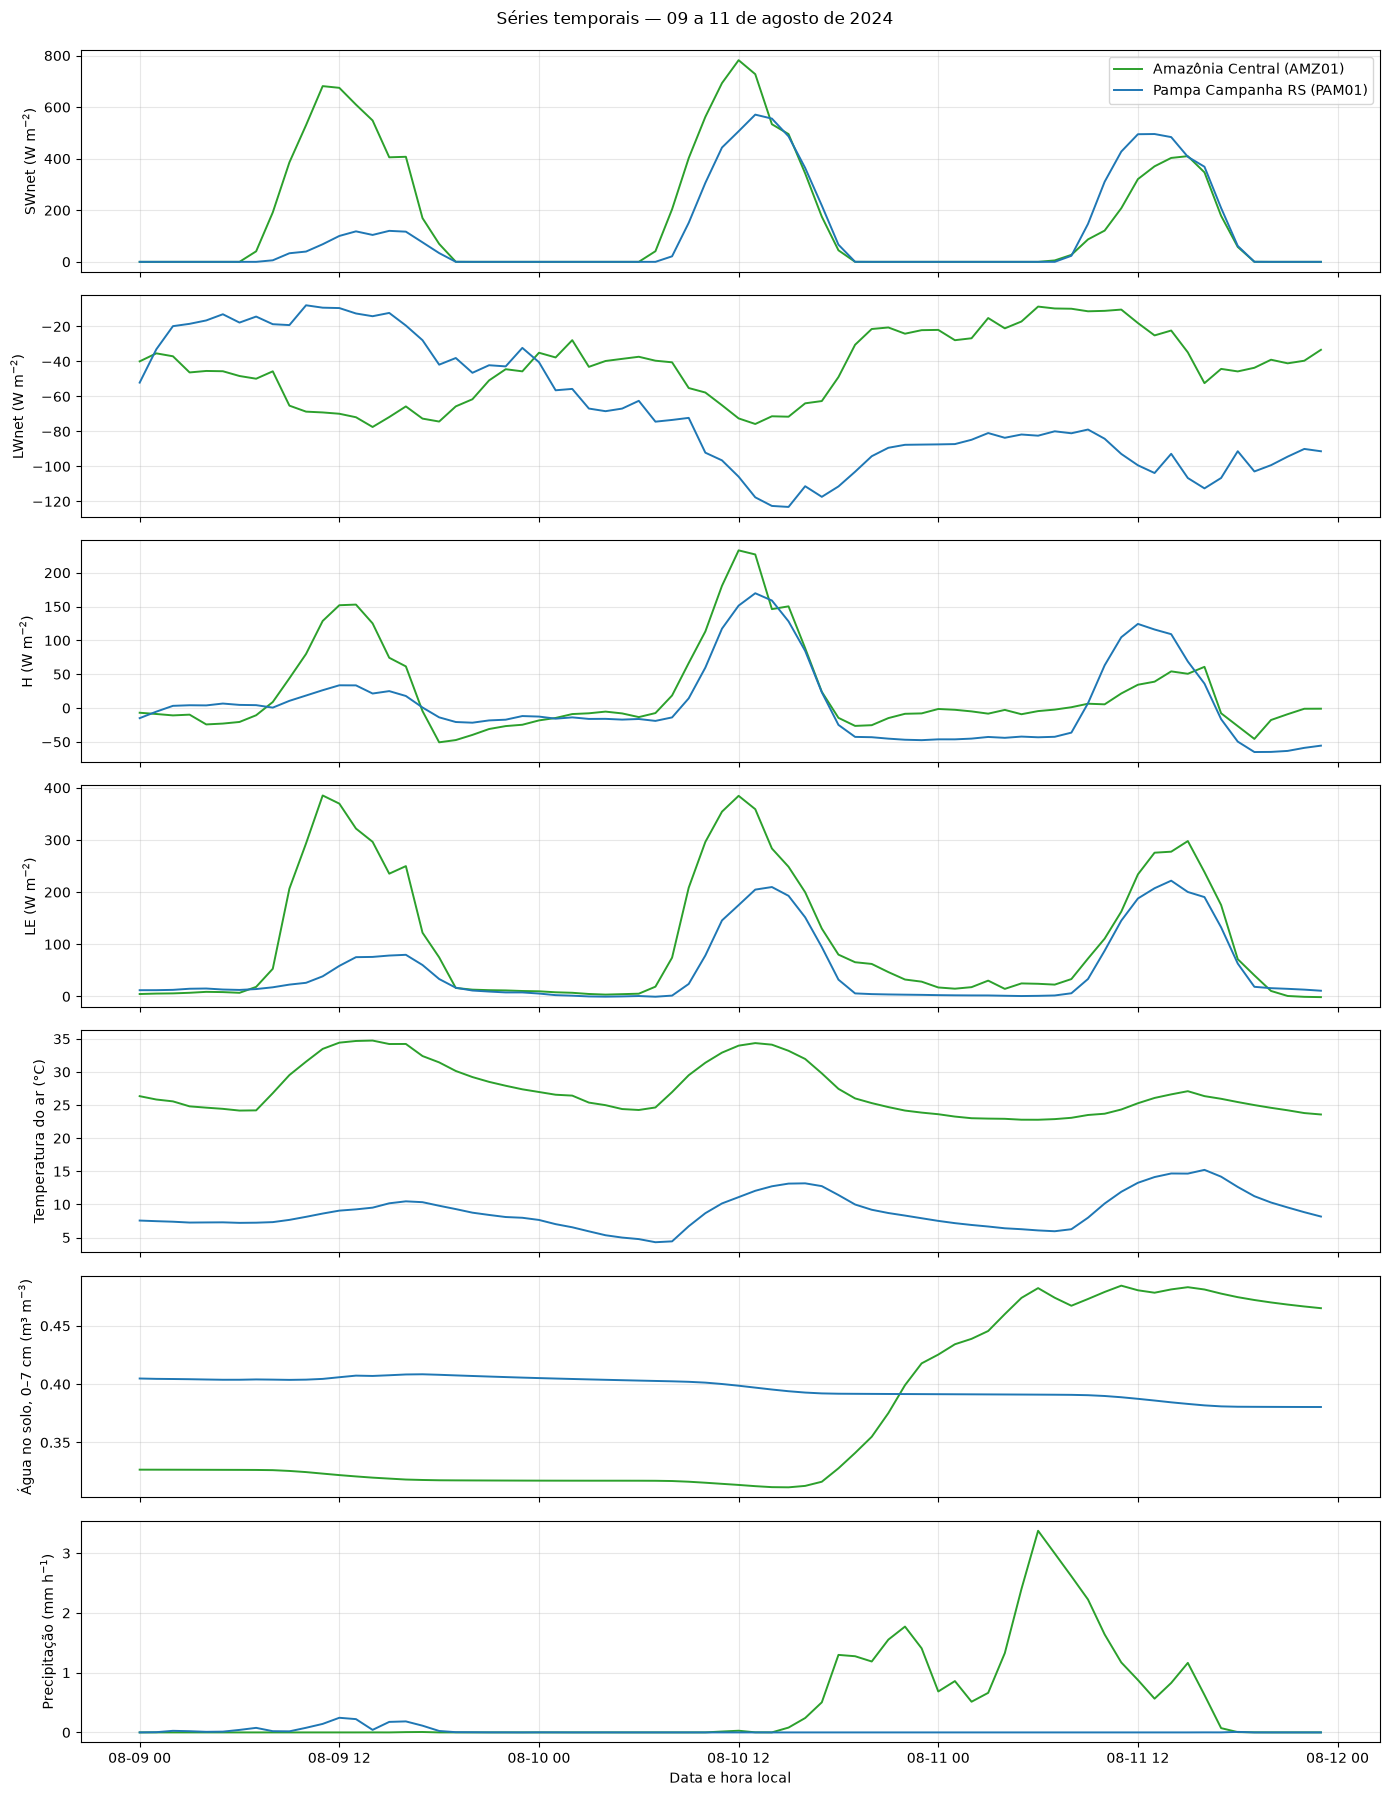

In [85]:
# Mesmo conjunto de variáveis, restrito a três dias consecutivos no horário local.
inicio_periodo = pd.Timestamp("2024-08-09 00:00")
fim_periodo = pd.Timestamp("2024-08-12 00:00")  # exclusivo: inclui 09, 10 e 11/08

figura_3_dias, eixos_3_dias = plt.subplots(
    nrows=len(variaveis_grafico), ncols=1, figsize=(14, 18), sharex=True
)

for eixo, (variavel, rotulo) in zip(eixos_3_dias, variaveis_grafico.items()):
    for region_id, nome_local in locais_grafico.items():
        dataframe = dataframes_por_local[region_id]
        datas = pd.to_datetime(dataframe["datetime_local"])
        no_periodo = (datas >= inicio_periodo) & (datas < fim_periodo)

        eixo.plot(
            datas[no_periodo],
            dataframe.loc[no_periodo, variavel],
            label=nome_local,
            color=cores[region_id],
            linewidth=1.4,
        )

    eixo.set_ylabel(rotulo)
    eixo.grid(True, alpha=0.3)

eixos_3_dias[0].legend(loc="upper right")
eixos_3_dias[-1].set_xlabel("Data e hora local")
figura_3_dias.suptitle(
    "Séries temporais — 09 a 11 de agosto de 2024", y=0.995
)
figura_3_dias.tight_layout()
plt.show()


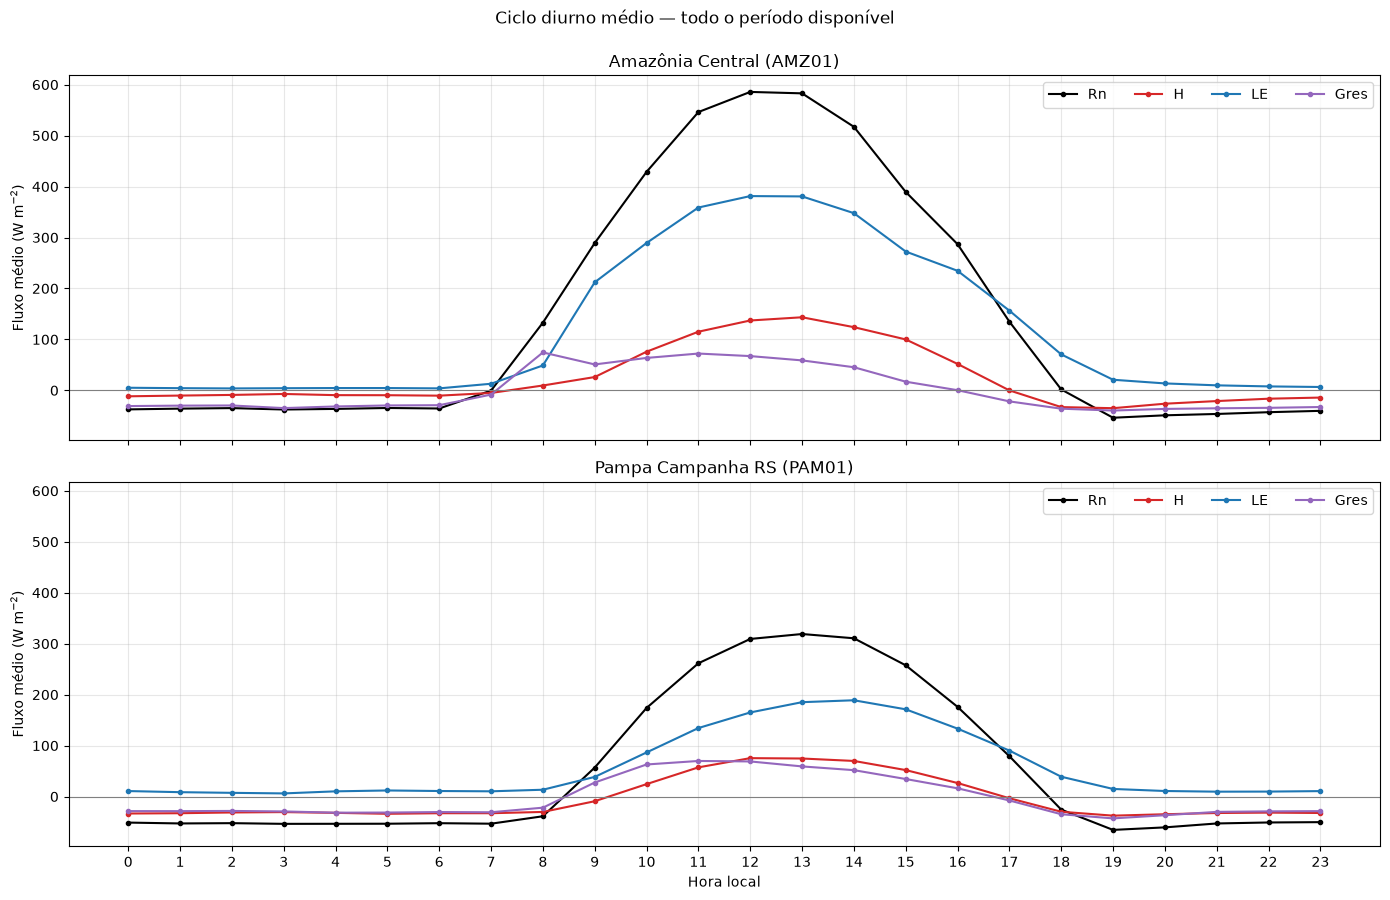

In [86]:
# Ciclo diurno médio usando todos os dados disponíveis de cada localidade.
variaveis_ciclo_diurno = ["Rn", "H", "LE", "Gres"]
cores_ciclo_diurno = {
    "Rn": "black",
    "H": "tab:red",
    "LE": "tab:blue",
    "Gres": "tab:purple",
}

medias_horarias_por_local = {}

for region_id in locais_grafico:
    dataframe = dataframes_por_local[region_id]
    medias_horarias = (
        dataframe.groupby("hour_local")[variaveis_ciclo_diurno]
        .mean()
        .reindex(range(24))
    )
    # Para B, exclui observações com |LE| < 10 antes de calcular as médias.
    dados_validos_B = dataframe.loc[dataframe["LE"].abs() >= 10]
    medias_para_B = (
        dados_validos_B.groupby("hour_local")[["H", "LE"]]
        .mean()
        .reindex(range(24))
    )
    # B é a razão entre H médio e LE médio das observações que passaram no filtro.
    medias_horarias["B"] = medias_para_B["H"] / medias_para_B["LE"]
    medias_horarias_por_local[region_id] = medias_horarias

figura_ciclo_diurno, eixos_ciclo_diurno = plt.subplots(
    nrows=len(locais_grafico), ncols=1, figsize=(14, 9), sharex=True, sharey=True
)

for eixo, (region_id, nome_local) in zip(eixos_ciclo_diurno, locais_grafico.items()):
    medias_horarias = medias_horarias_por_local[region_id]

    for variavel in variaveis_ciclo_diurno:
        eixo.plot(
            medias_horarias.index,
            medias_horarias[variavel],
            label=variavel,
            color=cores_ciclo_diurno[variavel],
            marker="o",
            markersize=3,
            linewidth=1.5,
        )

    eixo.axhline(0, color="gray", linewidth=0.8)
    eixo.set_title(nome_local)
    eixo.set_ylabel("Fluxo médio (W m$^{-2}$)")
    eixo.set_xticks(range(24))
    eixo.grid(True, alpha=0.3)
    eixo.legend(ncol=4, loc="upper right")

eixos_ciclo_diurno[-1].set_xlabel("Hora local")
figura_ciclo_diurno.suptitle(
    "Ciclo diurno médio — todo o período disponível", y=0.995
)
figura_ciclo_diurno.tight_layout()
plt.show()


In [87]:
# Maiores valores das curvas do ciclo diurno médio e suas horas locais.
resultados_maximos_ciclo = []

for region_id, nome_local in locais_grafico.items():
    medias_horarias = medias_horarias_por_local[region_id]

    for variavel in variaveis_ciclo_diurno:
        hora_do_maximo = medias_horarias[variavel].idxmax()
        resultados_maximos_ciclo.append(
            {
                "region_id": region_id,
                "local": nome_local,
                "variavel": variavel,
                "maior_media_W_m2": medias_horarias.loc[hora_do_maximo, variavel],
                "hora_local": hora_do_maximo,
            }
        )

tabela_maximos_ciclo_diurno = pd.DataFrame(resultados_maximos_ciclo).sort_values(
    ["region_id", "variavel"], ignore_index=True
)

display(tabela_maximos_ciclo_diurno)


,region_id,local,variavel,maior_media_W_m2,hora_local
0,AMZ01,Amazônia Central (AMZ01),Gres,74.452240,8
1,AMZ01,Amazônia Central (AMZ01),H,143.456923,13
2,AMZ01,Amazônia Central (AMZ01),LE,381.295626,12
3,AMZ01,Amazônia Central (AMZ01),Rn,585.710286,12
4,PAM01,Pampa Campanha RS (PAM01),Gres,69.833834,11
5,PAM01,Pampa Campanha RS (PAM01),H,75.368814,12
6,PAM01,Pampa Campanha RS (PAM01),LE,188.953431,14
7,PAM01,Pampa Campanha RS (PAM01),Rn,318.980300,13


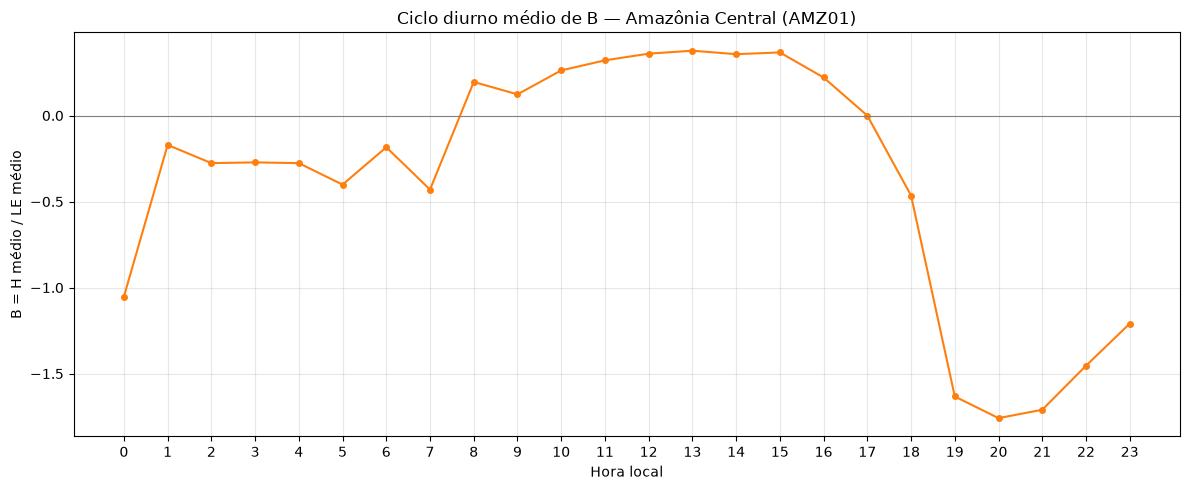

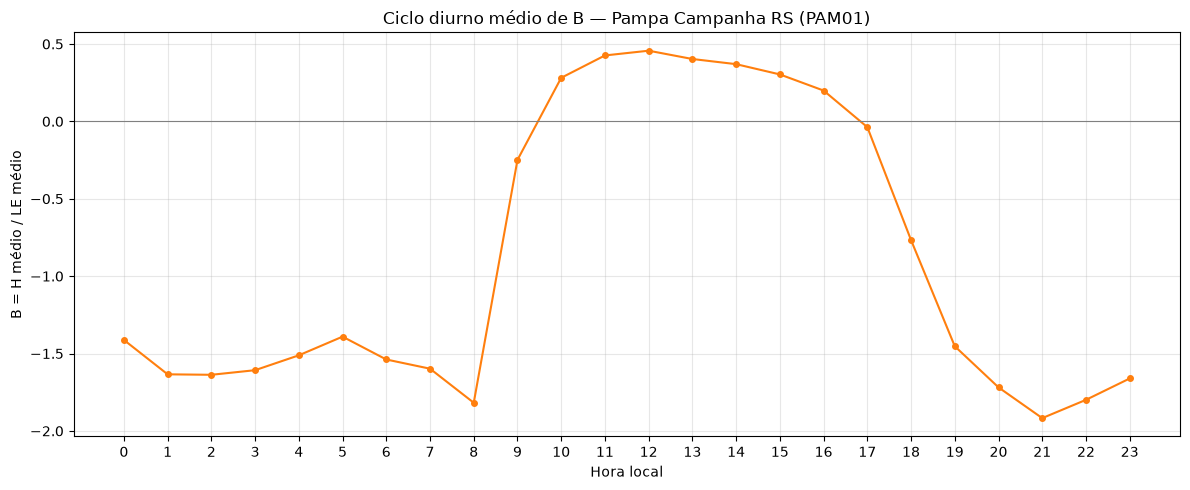

In [88]:
# Ciclo diurno médio da razão B = H médio / LE médio, um gráfico por localidade.
figuras_ciclo_B = {}
eixos_ciclo_B = {}

for region_id, nome_local in locais_grafico.items():
    medias_horarias = medias_horarias_por_local[region_id]
    figura_B, eixo_B = plt.subplots(figsize=(12, 5))

    eixo_B.plot(
        medias_horarias.index,
        medias_horarias["B"],
        color="tab:orange",
        marker="o",
        markersize=4,
        linewidth=1.5,
    )
    eixo_B.axhline(0, color="gray", linewidth=0.8)
    eixo_B.set_title(f"Ciclo diurno médio de B — {nome_local}")
    eixo_B.set_xlabel("Hora local")
    eixo_B.set_ylabel("B = H médio / LE médio")
    eixo_B.set_xticks(range(24))
    eixo_B.grid(True, alpha=0.3)
    figura_B.tight_layout()

    figuras_ciclo_B[region_id] = figura_B
    eixos_ciclo_B[region_id] = eixo_B
    plt.show()


In [89]:
# Médias diurnas no período todo. Considera-se dia quando SWnet > 0.
resultados_medias_diurnas = []

for region_id, nome_local in locais_grafico.items():
    dataframe = dataframes_por_local[region_id]
    dados_diurnos = dataframe.loc[dataframe["SWnet"] > 0]

    # Todas as médias usam somente observações com |LE| >= 10.
    dados_diurnos_validos = dados_diurnos.loc[dados_diurnos["LE"].abs() >= 10]

    resultados_medias_diurnas.append(
        {
            "region_id": region_id,
            "local": nome_local,
            "H_medio_diurno_W_m2": dados_diurnos_validos["H"].mean(),
            "LE_medio_diurno_W_m2": dados_diurnos_validos["LE"].mean(),
            "B_medio_diurno": (
                dados_diurnos_validos["H"].mean() / dados_diurnos_validos["LE"].mean()
            ),
            "n_observacoes_diurnas": len(dados_diurnos),
            "n_observacoes_utilizadas": len(dados_diurnos_validos),
        }
    )

tabela_medias_diurnas = pd.DataFrame(resultados_medias_diurnas)
display(tabela_medias_diurnas)


,region_id,local,H_medio_diurno_W_m2,LE_medio_diurno_W_m2,B_medio_diurno,n_observacoes_diurnas,n_observacoes_para_B
0,AMZ01,Amazônia Central (AMZ01),54.637575,214.371418,0.256464,182,174
1,PAM01,Pampa Campanha RS (PAM01),23.653294,106.389347,0.243880,165,151


In [90]:
# Médias noturnas no período todo. Considera-se noite quando SWnet <= 0.
resultados_medias_noturnas = []

for region_id, nome_local in locais_grafico.items():
    dataframe = dataframes_por_local[region_id]
    dados_noturnos = dataframe.loc[dataframe["SWnet"] <= 0]

    # Todas as médias usam somente observações com |LE| >= 10.
    dados_noturnos_validos = dados_noturnos.loc[dados_noturnos["LE"].abs() >= 10]

    resultados_medias_noturnas.append(
        {
            "region_id": region_id,
            "local": nome_local,
            "H_medio_noturno_W_m2": dados_noturnos_validos["H"].mean(),
            "LE_medio_noturno_W_m2": dados_noturnos_validos["LE"].mean(),
            "B_medio_noturno": (
                dados_noturnos_validos["H"].mean() / dados_noturnos_validos["LE"].mean()
            ),
            "n_observacoes_noturnas": len(dados_noturnos),
            "n_observacoes_utilizadas": len(dados_noturnos_validos),
        }
    )

tabela_medias_noturnas = pd.DataFrame(resultados_medias_noturnas)
display(tabela_medias_noturnas)


,region_id,local,H_medio_noturno_W_m2,LE_medio_noturno_W_m2,B_medio_noturno,n_observacoes_noturnas,n_observacoes_para_B
0,AMZ01,Amazônia Central (AMZ01),-13.161712,6.224534,-1.212475,154,31
1,PAM01,Pampa Campanha RS (PAM01),-32.648071,10.113805,-1.549882,171,66


In [91]:
# Médias do período completo: registros diurnos e noturnos juntos.
resultados_medias_totais = []

for region_id, nome_local in locais_grafico.items():
    dataframe = dataframes_por_local[region_id]

    # Todas as médias usam somente observações com |LE| >= 10.
    dados_validos = dataframe.loc[dataframe["LE"].abs() >= 10]

    resultados_medias_totais.append(
        {
            "region_id": region_id,
            "local": nome_local,
            "H_medio_total_W_m2": dados_validos["H"].mean(),
            "LE_medio_total_W_m2": dados_validos["LE"].mean(),
            "B_medio_total": (
                dados_validos["H"].mean() / dados_validos["LE"].mean()
            ),
            "n_observacoes_totais": len(dataframe),
            "n_observacoes_utilizadas": len(dados_validos),
        }
    )

tabela_medias_totais = pd.DataFrame(resultados_medias_totais)
display(tabela_medias_totais)


,region_id,local,H_medio_total_W_m2,LE_medio_total_W_m2,B_medio_total,n_observacoes_totais,n_observacoes_para_B
0,AMZ01,Amazônia Central (AMZ01),23.562901,118.970763,0.235957,336,205
1,PAM01,Pampa Campanha RS (PAM01),-5.000079,57.391973,0.117932,336,217


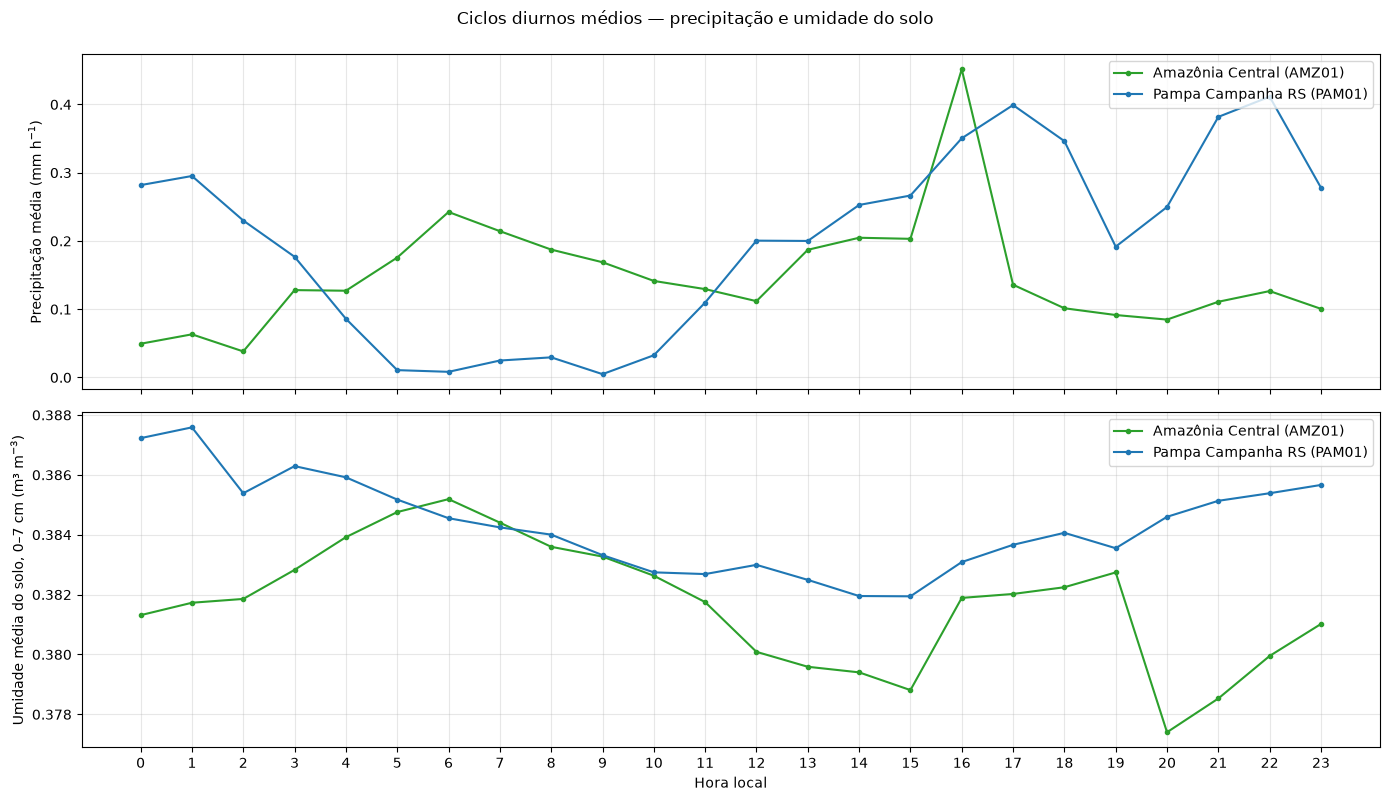

In [92]:
# Ciclos diurnos médios de precipitação e umidade do solo no período completo.
variaveis_hidrologicas = {
    "precip_mm_h": "Precipitação média (mm h$^{-1}$)",
    "soil_water_0_7cm": "Umidade média do solo, 0–7 cm (m³ m$^{-3}$)",
}

medias_horarias_hidrologicas_por_local = {}

for region_id in locais_grafico:
    dataframe = dataframes_por_local[region_id]
    medias_horarias_hidrologicas_por_local[region_id] = (
        dataframe.groupby("hour_local")[list(variaveis_hidrologicas)]
        .mean()
        .reindex(range(24))
    )

figura_ciclo_hidrologico, eixos_ciclo_hidrologico = plt.subplots(
    nrows=len(variaveis_hidrologicas), ncols=1, figsize=(14, 8), sharex=True
)

for eixo, (variavel, rotulo) in zip(
    eixos_ciclo_hidrologico, variaveis_hidrologicas.items()
):
    for region_id, nome_local in locais_grafico.items():
        medias_horarias = medias_horarias_hidrologicas_por_local[region_id]
        eixo.plot(
            medias_horarias.index,
            medias_horarias[variavel],
            label=nome_local,
            color=cores[region_id],
            marker="o",
            markersize=3,
            linewidth=1.5,
        )

    eixo.set_ylabel(rotulo)
    eixo.set_xticks(range(24))
    eixo.grid(True, alpha=0.3)
    eixo.legend(loc="upper right")

eixos_ciclo_hidrologico[-1].set_xlabel("Hora local")
figura_ciclo_hidrologico.suptitle(
    "Ciclos diurnos médios — precipitação e umidade do solo", y=0.995
)
figura_ciclo_hidrologico.tight_layout()
plt.show()


In [ ]:
# Exporta todas as tabelas e gráficos para pastas organizadas.
pasta_resultados = Path("resultados_analise")
pasta_tabelas = pasta_resultados / "tabelas"
pasta_dados_locais = pasta_tabelas / "dataframes_locais"
pasta_ciclos_energia = pasta_tabelas / "ciclos_diurnos_energia"
pasta_ciclos_hidrologicos = pasta_tabelas / "ciclos_diurnos_hidrologicos"
pasta_graficos = pasta_resultados / "graficos"
pasta_imagens_tabelas = pasta_resultados / "imagens_tabelas"

for pasta in [
    pasta_dados_locais,
    pasta_ciclos_energia,
    pasta_ciclos_hidrologicos,
    pasta_graficos,
    pasta_imagens_tabelas,
]:
    pasta.mkdir(parents=True, exist_ok=True)

arquivos_exportados = []

# DataFrames completos, com Rn e Gres, um CSV por localidade.
for region_id, dataframe in dataframes_por_local.items():
    caminho = pasta_dados_locais / f"{region_id}.csv"
    dataframe.to_csv(caminho, index=False, encoding="utf-8-sig")
    arquivos_exportados.append(caminho)

tabelas_resumo = {
    "resumo_locais.csv": resumo_locais,
    "maximos_fluxos_09_11_agosto.csv": maximos_fluxos,
    "maximos_ciclo_diurno.csv": tabela_maximos_ciclo_diurno,
    "medias_diurnas.csv": tabela_medias_diurnas,
    "medias_noturnas.csv": tabela_medias_noturnas,
    "medias_periodo_completo.csv": tabela_medias_totais,
}

for nome_arquivo, tabela in tabelas_resumo.items():
    caminho = pasta_tabelas / nome_arquivo
    tabela.to_csv(caminho, index=False, encoding="utf-8-sig")
    arquivos_exportados.append(caminho)

# Tabelas das 24 médias horárias dos ciclos diurnos.
for region_id, tabela in medias_horarias_por_local.items():
    caminho = pasta_ciclos_energia / f"{region_id}_ciclo_diurno_energia.csv"
    tabela.rename_axis("hora_local").to_csv(caminho, encoding="utf-8-sig")
    arquivos_exportados.append(caminho)

for region_id, tabela in medias_horarias_hidrologicas_por_local.items():
    caminho = pasta_ciclos_hidrologicos / f"{region_id}_ciclo_diurno_hidrologico.csv"
    tabela.rename_axis("hora_local").to_csv(caminho, encoding="utf-8-sig")
    arquivos_exportados.append(caminho)

graficos = {
    "series_temporais_periodo_completo.png": figura,
    "series_temporais_09_a_11_agosto.png": figura_3_dias,
    "balanco_energia_09_a_11_agosto.png": figura_balanco,
    "ciclo_diurno_medio_energia.png": figura_ciclo_diurno,
    "ciclo_diurno_medio_B_AMZ01.png": figuras_ciclo_B["AMZ01"],
    "ciclo_diurno_medio_B_PAM01.png": figuras_ciclo_B["PAM01"],
    "ciclo_diurno_medio_hidrologico.png": figura_ciclo_hidrologico,
}

for nome_arquivo, figura_exportada in graficos.items():
    caminho = pasta_graficos / nome_arquivo
    figura_exportada.savefig(caminho, dpi=300, bbox_inches="tight")
    arquivos_exportados.append(caminho)

def numero_formatado(valor):
    return f"{valor:.3f}".replace(".", ",")


def criar_imagem_tabela(tabela, titulo, subtitulo, caminho):
    """Salva uma tabela compacta e legível como imagem PNG."""
    altura = max(3.0, 1.5 + 0.52 * len(tabela))
    figura_tabela, eixo_tabela = plt.subplots(figsize=(13, altura))
    figura_tabela.subplots_adjust(top=0.76, bottom=0.15, left=0.03, right=0.97)
    eixo_tabela.axis("off")

    tabela_mpl = eixo_tabela.table(
        cellText=tabela.values,
        colLabels=tabela.columns,
        cellLoc="center",
        colLoc="center",
        bbox=[0, 0, 1, 1],
    )
    tabela_mpl.auto_set_font_size(False)
    tabela_mpl.set_fontsize(10)
    tabela_mpl.auto_set_column_width(col=list(range(len(tabela.columns))))

    for (linha, coluna), celula in tabela_mpl.get_celld().items():
        celula.set_edgecolor("#D6E1E5")
        if linha == 0:
            celula.set_facecolor("#146C6C")
            celula.set_text_props(color="white", weight="bold")
        else:
            celula.set_facecolor("#F3F8F7" if linha % 2 else "#E5F0ED")

    figura_tabela.suptitle(titulo, fontsize=16, fontweight="bold", color="#123B3B", y=0.96)
    figura_tabela.text(0.5, 0.05, subtitulo, ha="center", fontsize=9, color="#405050")
    figura_tabela.savefig(caminho, dpi=300, bbox_inches="tight", facecolor="white")
    plt.close(figura_tabela)


def tabela_medias_para_imagem(tabela, periodo):
    return pd.DataFrame(
        {
            "Localidade": tabela["local"],
            "H médio\n(W m⁻²)": tabela[f"H_medio_{periodo}_W_m2"].map(numero_formatado),
            "LE médio\n(W m⁻²)": tabela[f"LE_medio_{periodo}_W_m2"].map(numero_formatado),
            "β médio\n(H̄ / LĒ)": tabela[f"B_medio_{periodo}"].map(numero_formatado),
        }
    )


tabelas_em_imagem = {
    "maximos_ciclo_diurno_medio.png": (
        pd.DataFrame(
            {
                "Localidade": tabela_maximos_ciclo_diurno["local"],
                "Variável": tabela_maximos_ciclo_diurno["variavel"],
                "Máximo médio\n(W m⁻²)": tabela_maximos_ciclo_diurno["maior_media_W_m2"].map(numero_formatado),
                "Hora local": tabela_maximos_ciclo_diurno["hora_local"].map(lambda hora: f"{int(hora)} h"),
            }
        ),
        "Máximos do ciclo diurno médio",
        "Valores médios horários máximos no período completo.",
    ),
    "maximos_fluxos_09_a_11_agosto.png": (
        pd.DataFrame(
            {
                "Localidade": maximos_fluxos["local"],
                "Variável": maximos_fluxos["variavel"],
                "Máximo\n(W m⁻²)": maximos_fluxos["valor_maximo_W_m2"].map(numero_formatado),
                "Data e hora local": maximos_fluxos["data_hora_local"].dt.strftime("%d/%m/%Y %Hh"),
            }
        ),
        "Máximos de Rn, H e LE — 09 a 11 de agosto",
        "Dados horários; data e hora no fuso local de cada localidade.",
    ),
    "medias_diurnas.png": (
        tabela_medias_para_imagem(tabela_medias_diurnas, "diurno"),
        "Médias diurnas — período completo",
        "Dia: SWnet > 0. Todas as médias usam apenas registros com |LE| ≥ 10.",
    ),
    "medias_noturnas.png": (
        tabela_medias_para_imagem(tabela_medias_noturnas, "noturno"),
        "Médias noturnas — período completo",
        "Noite: SWnet ≤ 0. Todas as médias usam apenas registros com |LE| ≥ 10.",
    ),
    "medias_totais.png": (
        tabela_medias_para_imagem(tabela_medias_totais, "total"),
        "Médias totais — período completo",
        "Registros diurnos e noturnos juntos; todas as médias usam |LE| ≥ 10.",
    ),
}

for nome_arquivo, (tabela, titulo, subtitulo) in tabelas_em_imagem.items():
    caminho = pasta_imagens_tabelas / nome_arquivo
    criar_imagem_tabela(tabela, titulo, subtitulo, caminho)
    arquivos_exportados.append(caminho)

print(f"{len(arquivos_exportados)} arquivos exportados em: {pasta_resultados.resolve()}")
